In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('placement.csv')

In [4]:
df.shape

(1000, 3)

In [7]:
df.sample(5)

,cgpa,placement_exam_marks,placed
978,6.78,12.0,0
439,6.67,10.0,1
519,6.60,8.0,1
969,6.86,41.0,0
80,6.87,46.0,1


/tmp/ipykernel_608/1777901540.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/tmp/ipykernel_608/1777901540.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


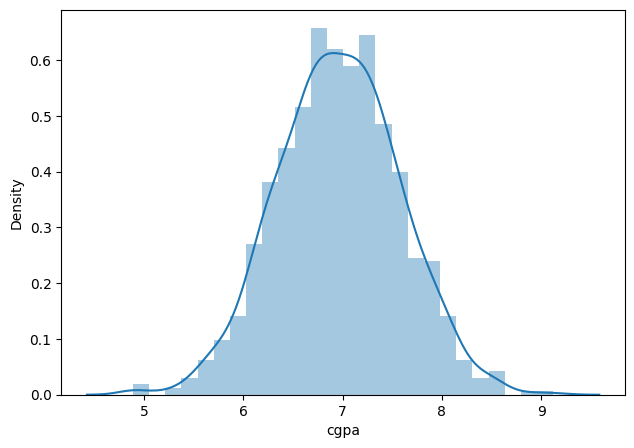

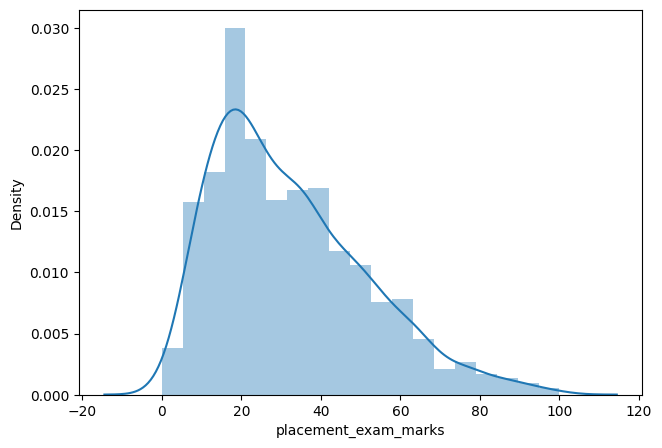

In [9]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.figure(figsize=(16,5))
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [10]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [11]:
print("Mean value of cgpa", df['cgpa'].mean())
print("std value of cgpa" , df['cgpa'].std())
print("std value of cgpa" , df['cgpa'].min())
print("std value of cgpa" , df['cgpa'].max())

Mean value of cgpa 6.96124
std value of cgpa 0.6158978751323894
std value of cgpa 4.89
std value of cgpa 9.12


Finding boundary values:-

In [13]:
print("Highest allowed", df['cgpa'].mean() +3*df['cgpa'].std())
print("Lowest allowed", df['cgpa'].mean() -3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


Finding the outliers


In [15]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11 )]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# **Trimming**

In [17]:
new_df= df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# Approach 2

In [36]:
# Calculating the Z-score
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()


In [40]:
df.drop('cgpa_zcore', axis=1, inplace=True)

In [41]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [42]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [43]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [44]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [46]:
# Trimming of cgpa_zscore
new_zscore_df=df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]
new_zscore_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping

In [47]:
upper_limit= df['cgpa'].mean() +3 * df['cgpa'].std()
lower_limit= df['cgpa'].mean() -3 * df['cgpa'].std()

In [48]:
lower_limit

np.float64(5.113546374602832)

In [49]:
upper_limit

np.float64(8.808933625397168)

In [50]:
df['cgpa'] = np.where(
    df['cgpa']> upper_limit,
    upper_limit,
    np.where(
        df['cgpa']< lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [51]:
df.shape

(1000, 4)

In [52]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934
